# Assignment 2 — Think Like a Data Analyst
 Course:  BIT 4.1 — Fundamentals of AI and Data Analytics
 Instructor: Lucas Silva
 Dataset:  Telecom Customer Churn 

In [180]:
import pandas as pd
import matplotlib.pyplot as plt

  1. Load the Dataset

In [181]:
df = pd.read_csv('elco-Customer-Churn-selected-columns.csv', sep=';')


 2. Dataset Description

In [182]:
df.head() 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No


In [183]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   customerID       7043 non-null   str  
 1   gender           7043 non-null   str  
 2   SeniorCitizen    7043 non-null   int64
 3   Partner          7043 non-null   str  
 4   Dependents       7043 non-null   str  
 5   tenure           7043 non-null   int64
 6   PhoneService     7043 non-null   str  
 7   MultipleLines    7043 non-null   str  
 8   InternetService  7043 non-null   str  
 9   OnlineSecurity   7043 non-null   str  
dtypes: int64(2), str(8)
memory usage: 550.4 KB


In [184]:
df.shape 

(7043, 10)

 3. Data Quality

3.1 Checking missing value 

In [185]:
df.isna().sum()

customerID         0
gender             0
SeniorCitizen      0
Partner            0
Dependents         0
tenure             0
PhoneService       0
MultipleLines      0
InternetService    0
OnlineSecurity     0
dtype: int64

No missing values found. 

3.2 checking duplicates value

In [186]:
df.duplicated().sum()

np.int64(0)

 No duplicates found. 

  3.3 Incosistent Categories 

In [187]:
df['gender'].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

In [188]:
df['MultipleLines'].value_counts()

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

In [189]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [190]:
df['OnlineSecurity'].value_counts()

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

 3.4 Outliers

In [191]:
Q1 = df['tenure'].quantile(0.25)
Q3 = df['tenure'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['tenure'] < lower) | (df['tenure'] > upper)]
print('Lower fence:', lower)
print('Upper fence:', upper)
print('Number of outliers:', len(outliers))

Lower fence: -60.0
Upper fence: 124.0
Number of outliers: 0


All tenure values are between 0 and 72 — everything is inside the fence → no outliers → data is clean 

 3.5 Wrong format

In [192]:
print(df.dtypes)

customerID           str
gender               str
SeniorCitizen      int64
Partner              str
Dependents           str
tenure             int64
PhoneService         str
MultipleLines        str
InternetService      str
OnlineSecurity       str
dtype: object


 4. Basic Statistics 

In [193]:
df.describe()

,SeniorCitizen,tenure
count,7043.000000,7043.000000
mean,0.162147,32.371149
std,0.368612,24.559481
min,0.000000,0.000000
25%,0.000000,9.000000
50%,0.000000,29.000000
75%,0.000000,55.000000
max,1.000000,72.000000


In [194]:
print('Mean:   ', df['tenure'].mean())
print('Median: ', df['tenure'].median())
print('Min:    ', df['tenure'].min())
print('Max:    ', df['tenure'].max())

Mean:    32.37114865824223
Median:  29.0
Min:     0
Max:     72


 5. Category counts

In [195]:
print(df['gender'].value_counts())

gender
Male      3555
Female    3488
Name: count, dtype: int64


In [196]:
print(df['InternetService'].value_counts())

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


In [197]:
print(df['Partner'].value_counts)


<bound method IndexOpsMixin.value_counts of 0       Yes
1        No
2        No
3        No
4        No
       ... 
7038    Yes
7039    Yes
7040    Yes
7041    Yes
7042     No
Name: Partner, Length: 7043, dtype: str>


 6. Charts

# Gender Distributions chart

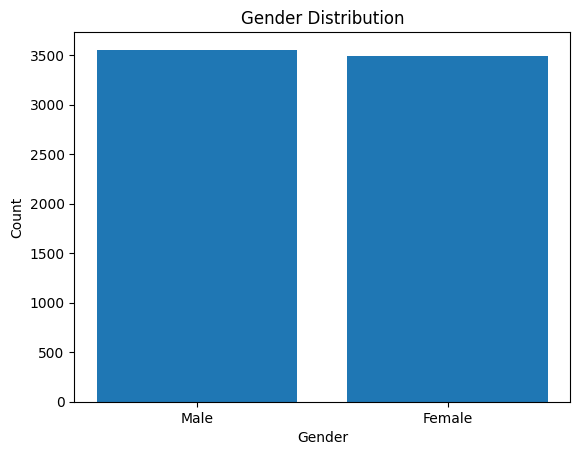

In [198]:
gender_counts = df['gender'].value_counts()
plt.bar(gender_counts.index, gender_counts.values)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

# Tenure distributions 

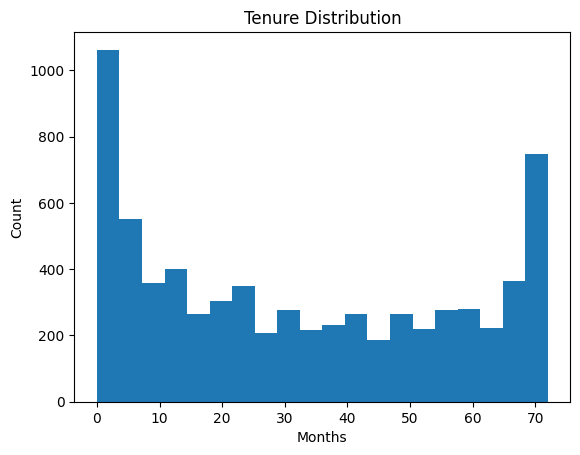

In [199]:
plt.hist(df['tenure'], bins=20)
plt.title('Tenure Distribution')
plt.xlabel('Months')
plt.ylabel('Count')
plt.show()

# Internet Service Distribution

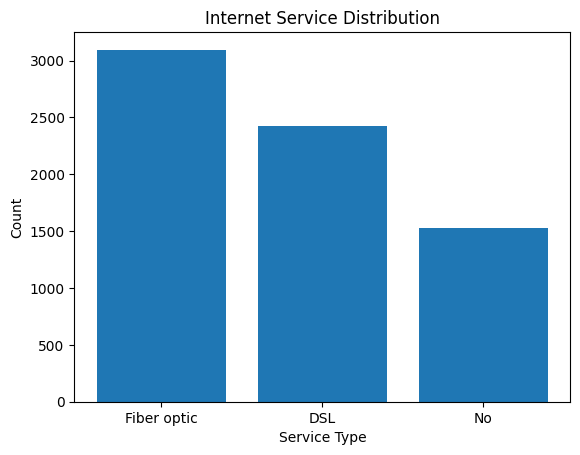

In [200]:
internet_counts = df['InternetService'].value_counts()
plt.bar(internet_counts.index, internet_counts.values)
plt.title('Internet Service Distribution')
plt.xlabel('Service Type')
plt.ylabel('Count')
plt.show()

# Senior Citizen Distribution

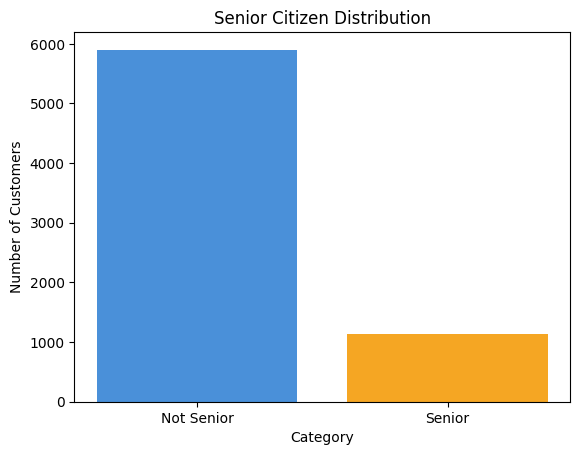

In [201]:
senior_counts = df['SeniorCitizen'].map({0: 'Not Senior', 1: 'Senior'}).value_counts()
plt.bar(senior_counts.index, senior_counts.values, color=['#4A90D9', '#F5A623'])
plt.title('Senior Citizen Distribution')
plt.xlabel('Category')
plt.ylabel('Number of Customers')
plt.show()

# 7. Conclusion

1. What the Data Reveals

The Telecom Customer Churn dataset contains 7,043 customers and 10 columns.
After following the Data Analytics Lifecycle from class :
Question → Collect → Understand → Clean → Analyse → Visualise → Interpret → Decide

---


2. Data Quality Findings

1.Missing Values: Zero missing values found across all 10 columns
2 Duplicates: Zero duplicate rows found
3.Inconsistent Categories: All categorical columns are clean with no typos or mixed casing
4.Outliers:No outliers detected in tenure using the IQR method (lower fence = -60, upper fence = 124)
5.Wrong Format:All columns have correct data types — no format corrections needed

---
 
3. Basic Statistics Findings

Tenure: Mean = 32.37 months, Median = 29 months, Min = 0, Max = 72 months
Senior Citizens: Only 16.2% of customers are senior citizens (1,142 out of 7,043)
Gender: Nearly balanced — 3,555 Male and 3,488 Female
Internet Service: Fiber optic is most popular (3,096), followed by DSL (2,421)
Phone Service: 6,361 customers have phone service — the core product

---

4. Why It Matters

The dataset is clean and reliable with no quality issues.
The typical customer is a non-senior adult with phone service and fiber optic internet.
Tenure has a wide spread (std = 24.56 months) showing customers either
leave early or stay very long — this pattern needs further investigation
to understand why customers leave and how to improve retention.